# FNO for McKean-Vlasov

Learns the operator W(x) -> rho(x,t) for the 1D McKean-Vlasov equation on [0,1) x [0,T].
Input: interaction potential W, shape (N,).
Output: density rho, shape (N, N) (space x time).

In [ ]:
# Imports
import numpy as np
import sys

import torch
from torch.utils.data import DataLoader, TensorDataset

import neuralop
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.utils import count_model_params
from torch.nn import functional as F

import matplotlib.pyplot as plt
from _helper_McKean_Vlasov import load_dataset_mckean_vlasov, get_resolution


In [31]:
# ===== HYPERPARAMETERS =====

# === Data ===
data_n_train        = 4500
data_n_test         = 500
data_train_resolution = 64   # NX = NT = 64, so spacetime grid is 64x64
data_test_resolutions = [64, 128]
data_batch_size       = 32
data_test_batch_sizes = [32, 32]

# === Model ===
# Input:  W(x)    shape (batch, 1, N)     -- 1D spatial field
# Output: rho(x,t) shape (batch, 1, N, N) -- 2D spacetime field
# We treat the problem as 2D: space x time
FNO_n_modes          = (20, 20)  # Fourier modes in (space, time)
FNO_in_channels      = 4
FNO_out_channels     = 1
FNO_hidden_channels  = 32
FNO_n_layers         = 6
FNO_factorization    = "tucker"
FNO_nonlinearity     = F.gelu

# === Training ===
TRAIN_epochs = 500


In [ ]:
from McKean_Vlasov_data_generator import initial_condition
def make_data_loader(W, rho, batch_size, shuffle=True):
    n, N = W.shape
    x_grid = np.linspace(0, 1, N, endpoint=False)
    t_grid = np.linspace(0, 1, N, endpoint=False)
    XX, TT = np.meshgrid(x_grid, t_grid, indexing='ij')  # (N, N)

    W_exp   = np.repeat(W[:, :, np.newaxis], N, axis=2)   # (n, N, N)
    X_enc   = np.tile(XX[np.newaxis], (n, 1, 1))           # (n, N, N)
    T_enc   = np.tile(TT[np.newaxis], (n, 1, 1))           # (n, N, N)

    phi     = initial_condition(x_grid)                    # (N,)
    phi_2d  = np.tile(phi[:, np.newaxis], (1, N))          # (N, N)
    phi_enc = np.tile(phi_2d[np.newaxis], (n, 1, 1))       # (n, N, N)

    inp = np.stack([W_exp, X_enc, T_enc, phi_enc], axis=1) # (n, 4, N, N)
    out = rho[:, np.newaxis, :, :]                          # (n, 1, N, N)

    def collate_fn(batch):
        xs = torch.stack([b[0] for b in batch])
        ys = torch.stack([b[1] for b in batch])
        return {"x": xs, "y": ys}

    x = torch.tensor(inp, dtype=torch.float32)
    y = torch.tensor(out, dtype=torch.float32)
    ds = TensorDataset(x, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=1, pin_memory=True,
                      persistent_workers=False, collate_fn=collate_fn)


In [33]:
# Activate GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [34]:
# Load McKean-Vlasov dataset
dataset = load_dataset_mckean_vlasov("mckean_vlasov_dataset.npz")

# Training data at train resolution
W_all, rho_all = get_resolution(dataset, data_train_resolution)

W_train   = W_all[:data_n_train]
rho_train = rho_all[:data_n_train]
W_test    = W_all[data_n_train:data_n_train + data_n_test]
rho_test  = rho_all[data_n_train:data_n_train + data_n_test]

# ── Normalisation ──────────────────────────────────────────────────────────
W_mean, W_std     = W_train.mean(),   W_train.std()
rho_mean, rho_std = rho_train.mean(), rho_train.std()

W_train_n   = (W_train   - W_mean)   / W_std
rho_train_n = (rho_train - rho_mean) / rho_std
W_test_n    = (W_test    - W_mean)   / W_std
rho_test_n  = (rho_test  - rho_mean) / rho_std

# ── Data loaders ───────────────────────────────────────────────────────────
train_loader = make_data_loader(W_train_n, rho_train_n, data_batch_size, shuffle=True)

test_loaders = {}
for res, bsize in zip(data_test_resolutions, data_test_batch_sizes):
    W_r, rho_r = get_resolution(dataset, res)
    W_t   = (W_r[data_n_train:data_n_train + data_n_test]   - W_mean) / W_std
    rho_t = (rho_r[data_n_train:data_n_train + data_n_test] - rho_mean) / rho_std
    test_loaders[res] = make_data_loader(W_t, rho_t, bsize, shuffle=False)

# Save normalisation constants for use in likelihood
print(f"W:   mean={W_mean:.4f}, std={W_std:.4f}")
print(f"rho: mean={rho_mean:.4f}, std={rho_std:.4f}")


W:   mean=0.0000, std=4.0000
rho: mean=0.9922, std=0.6591


In [35]:
# Instantiate Model
# FNO maps (batch, 1, N, N) -> (batch, 1, N, N)
# Input channel: W(x) broadcast over time axis
# Output channel: rho(x, t)
model = FNO(
    n_modes=FNO_n_modes,
    in_channels=FNO_in_channels,
    out_channels=FNO_out_channels,
    hidden_channels=FNO_hidden_channels,
    n_layers=FNO_n_layers,
    factorization=FNO_factorization,
    non_linearity=FNO_nonlinearity,
)

model = model.to(device)
n_params = count_model_params(model)
print(f"Model parameters: {n_params}")
sys.stdout.flush()

optimizer = AdamW(model.parameters(), lr=8e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TRAIN_epochs)

l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

train_loss = h1loss
eval_losses = {"h1": h1loss, "l2": l2loss}


Model parameters: 2751853


In [38]:
import os

MODEL_PATH = "./checkpoints_mckean_vlasov/fno_mckean_vlasov.pt"

if os.path.exists(MODEL_PATH):
    # Load saved model
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print(f"Loaded model from {MODEL_PATH}")

else:
    # Train from scratch
    print("No saved model found, training from scratch...")
    torch.serialization.add_safe_globals([torch._C._nn.gelu])
    torch.serialization.add_safe_globals([neuralop.layers.spectral_convolution.SpectralConv])

    trainer = Trainer(
        model=model,
        n_epochs=TRAIN_epochs,
        device=device,
        data_processor=None,
        wandb_log=False,
        eval_interval=5,
        use_distributed=False,
        verbose=True,
    )

    # trainer.train(
    #     train_loader=train_loader,
    #     test_loaders={},
    #     optimizer=optimizer,
    #     scheduler=scheduler,
    #     regularizer=False,
    #     training_loss=train_loss,
    #     save_every=5,
    #     save_dir="./checkpoints_mckean_vlasov",
    # )

    
    # To resume from checkpoints instead, comment above and uncomment below:
    trainer.train(
        train_loader=train_loader,
        test_loaders={},
        optimizer=optimizer,
        scheduler=scheduler,
        regularizer=False,
        training_loss=train_loss,
        resume_from_dir="./checkpoints_mckean_vlasov",
        save_dir="./checkpoints_mckean_vlasov",
    )

    # Save model after training
    os.makedirs("./checkpoints_mckean_vlasov", exist_ok=True)
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")


No saved model found, training from scratch...
Trainer resuming from epoch 15
Training on 4500 samples
Testing on [] samples         on resolutions [].
[15] time=7.03, avg_loss=0.3487, train_err=11.1300
Eval: 
[20] time=6.35, avg_loss=0.3388, train_err=10.8134
Eval: 
[25] time=6.59, avg_loss=0.3413, train_err=10.8922
Eval: 
[30] time=7.12, avg_loss=0.3415, train_err=10.8983
Eval: 
[35] time=7.30, avg_loss=0.3190, train_err=10.1802
Eval: 
[40] time=7.29, avg_loss=0.3454, train_err=11.0238
Eval: 
[45] time=7.29, avg_loss=0.3249, train_err=10.3694
Eval: 
[50] time=7.18, avg_loss=0.3246, train_err=10.3598
Eval: 
[55] time=7.33, avg_loss=0.3157, train_err=10.0762
Eval: 
[60] time=7.23, avg_loss=0.3143, train_err=10.0293
Eval: 
[65] time=7.34, avg_loss=0.3100, train_err=9.8947
Eval: 
[70] time=7.29, avg_loss=0.2969, train_err=9.4764
Eval: 
[75] time=6.66, avg_loss=0.2890, train_err=9.2239
Eval: 
[80] time=6.74, avg_loss=0.2898, train_err=9.2482
Eval: 
[85] time=7.18, avg_loss=0.2811, train_e

In [54]:
# === MCMC HYPERPARAMETERS ===
MCMC_delta = 0.0025  # can experiment later with adaptive delta, as in it gets smaller as the number of iterations increases.
MCMC_n_iterations = 20_000  # Most likely need it on the order of 100,000 to get good results, but we can test the code with fewer iterations first.
MCMC_tau = -1  # Smoothing parameter for the smooth threshold function. Higher values make it closer to a hard threshold, while lower values make it smoother. We can experiment with different values to see how it affects the results.


In [55]:
# MCMC helper functions

from McKean_Vlasov_data import sample_negative_laplacian

def build_fno_input(W_np, N):
    """Build 4-channel (1, 4, N, N) input tensor for FNO, normalised."""
    W_n    = (W_np - W_mean) / W_std
    x_grid = np.linspace(0, 1, N, endpoint=False)
    t_grid = np.linspace(0, 1, N, endpoint=False)
    XX, TT = np.meshgrid(x_grid, t_grid, indexing='ij')   # (N, N)
    W_exp  = np.repeat(W_n[:, np.newaxis], N, axis=1)     # (N, N)
    phi    = initial_condition(x_grid)                     # (N,)
    phi_enc = np.tile(phi[:, np.newaxis], (1, N))          # (N, N)
    inp    = np.stack([W_exp, XX, TT, phi_enc], axis=0)   # (4, N, N)
    return torch.tensor(inp[np.newaxis], dtype=torch.float32).to(device)  # (1, 4, N, N)


def log_likelihood(W_np, rho_obs_np, model, sigma=1.0):
    W_tensor = build_fno_input(W_np, W_np.shape[0])
    with torch.no_grad():
        rho_pred_n = model(W_tensor).cpu().numpy()[0, 0]
    rho_pred = rho_pred_n * rho_std + rho_mean
    return -0.5 * np.sum((rho_obs_np - rho_pred)**2) / sigma**2


def sample_W_prior(N=64):
    """Sample W from the prior N(0, (-Delta + tau^2 I)^{-alpha})."""
    return sample_negative_laplacian(sigma=4, tau=3, alpha=4, N=N)




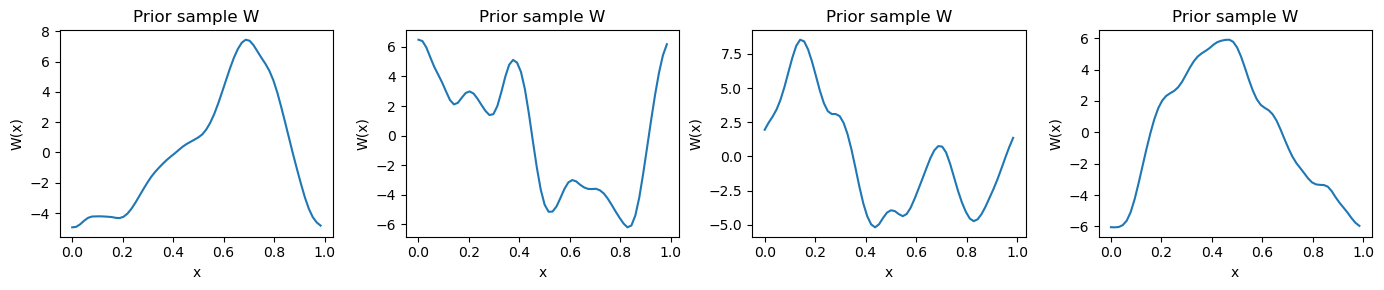

In [56]:
# Visualise a few prior samples of W
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
x_plot = np.linspace(0, 1, data_train_resolution, endpoint=False)
for ax in axes:
    W_sample = sample_W_prior(N=data_train_resolution)
    ax.plot(x_plot, W_sample)
    ax.set_xlabel("x")
    ax.set_ylabel("W(x)")
    ax.set_title("Prior sample W")
plt.tight_layout()
plt.show()


In [57]:
# Get a test observation: true rho(x,t) for one sample
W_obs_np, rho_obs_np = get_resolution(dataset, data_train_resolution)
W_obs_np   = W_obs_np[data_n_train]
rho_obs_np = rho_obs_np[data_n_train]
sigma = float(np.std(rho_obs_np))


In [58]:
from collections import deque

# === MCMC HYPERPARAMETERS ===
MCMC_delta        = 0.00025
MCMC_n_iterations = 40_000
target_acceptance = 0.234
adapt_interval    = 500
adapt_cutoff      = 20_000
delta_min, delta_max = 1e-6, 0.49

nll_window        = deque(maxlen=200)
n_accepted_window = 0
adapting          = True
theta_evolution   = []
loss_evolution    = []
accepted          = []

# Observed rho — keep as numpy
W_obs_np, rho_obs_np = get_resolution(dataset, data_train_resolution)
W_obs_np   = W_obs_np[data_n_train]    # numpy (N,)
rho_obs_np = rho_obs_np[data_n_train]  # numpy (N, N)

# Initial state — numpy only
u_0        = sample_W_prior(N=data_train_resolution)
ll_current = log_likelihood(u_0, rho_obs_np, model, sigma=sigma)

for i in range(MCMC_n_iterations):
    # pCN proposal — stays in numpy
    u_proposal = (np.sqrt(1 - 2 * MCMC_delta) * u_0
                  + np.sqrt(2 * MCMC_delta) * sample_W_prior(N=data_train_resolution))

    ll_proposal     = log_likelihood(u_proposal, rho_obs_np, model, sigma=sigma)
    acceptance_prob = min(1, np.exp(ll_proposal - ll_current))

    if np.random.rand() < acceptance_prob:
        u_0        = u_proposal
        ll_current = ll_proposal
        accepted.append(1)
        n_accepted_window += 1
    else:
        accepted.append(0)

    theta_evolution.append(u_0.copy())
    loss_evolution.append(ll_current)
    nll_window.append(-ll_current)

    if (i + 1) % adapt_interval == 0:
        acceptance_rate   = n_accepted_window / adapt_interval
        n_accepted_window = 0
        if adapting:
            factor     = np.exp(acceptance_rate - target_acceptance)
            MCMC_delta = float(np.clip(MCMC_delta * factor, delta_min, delta_max))
            if (i + 1) >= adapt_cutoff:
                adapting = False
                print(f">>> Adaptation frozen at delta={MCMC_delta:.6f}")
        avg_nll = np.mean(nll_window)
        print(f"Iteration {i+1}/{MCMC_n_iterations} | "
              f"accept={acceptance_rate:.3f} | delta={MCMC_delta:.6f} | "
              f"adapting={adapting} | avg NLL={avg_nll:.3f}")

Iteration 500/40000 | accept=0.924 | delta=0.000498 | adapting=True | avg NLL=2013.600
Iteration 1000/40000 | accept=0.382 | delta=0.000578 | adapting=True | avg NLL=184.347
Iteration 1500/40000 | accept=0.060 | delta=0.000486 | adapting=True | avg NLL=163.651
Iteration 2000/40000 | accept=0.042 | delta=0.000401 | adapting=True | avg NLL=135.099
Iteration 2500/40000 | accept=0.028 | delta=0.000326 | adapting=True | avg NLL=105.588
Iteration 3000/40000 | accept=0.060 | delta=0.000274 | adapting=True | avg NLL=93.918
Iteration 3500/40000 | accept=0.032 | delta=0.000224 | adapting=True | avg NLL=76.422
Iteration 4000/40000 | accept=0.066 | delta=0.000189 | adapting=True | avg NLL=70.539
Iteration 4500/40000 | accept=0.018 | delta=0.000153 | adapting=True | avg NLL=58.091
Iteration 5000/40000 | accept=0.076 | delta=0.000130 | adapting=True | avg NLL=57.852
Iteration 5500/40000 | accept=0.058 | delta=0.000109 | adapting=True | avg NLL=53.039
Iteration 6000/40000 | accept=0.098 | delta=0.000

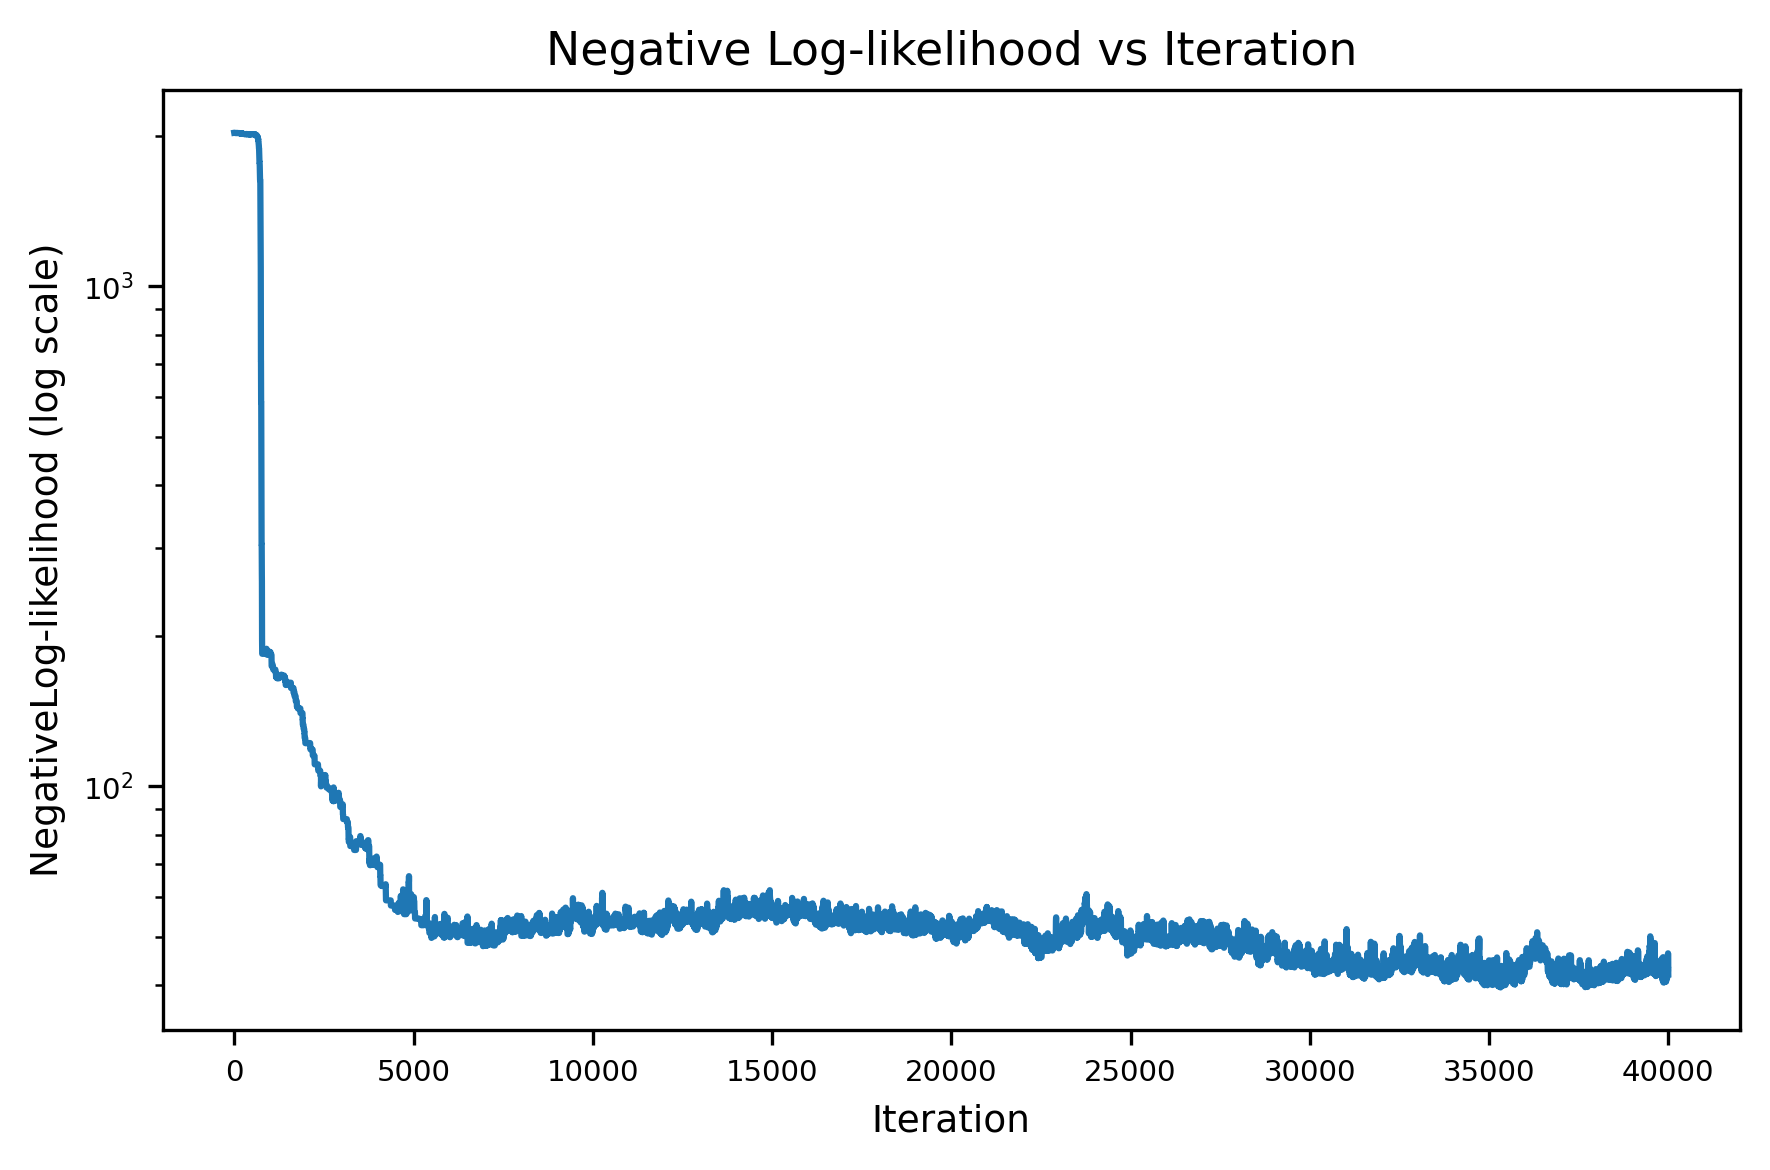

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
ax.plot(-np.array(loss_evolution))
ax.set_yscale('log')
ax.set_title("Negative Log-likelihood vs Iteration", fontsize=11, loc='center', pad=6)
ax.set_xlabel("Iteration", fontsize=9)
ax.set_ylabel("NegativeLog-likelihood (log scale)", fontsize=9)
ax.tick_params(labelsize=7)
plt.tight_layout()
# plt.savefig('figures_for_report/loss_curve.png', bbox_inches='tight', dpi=300)
plt.show()

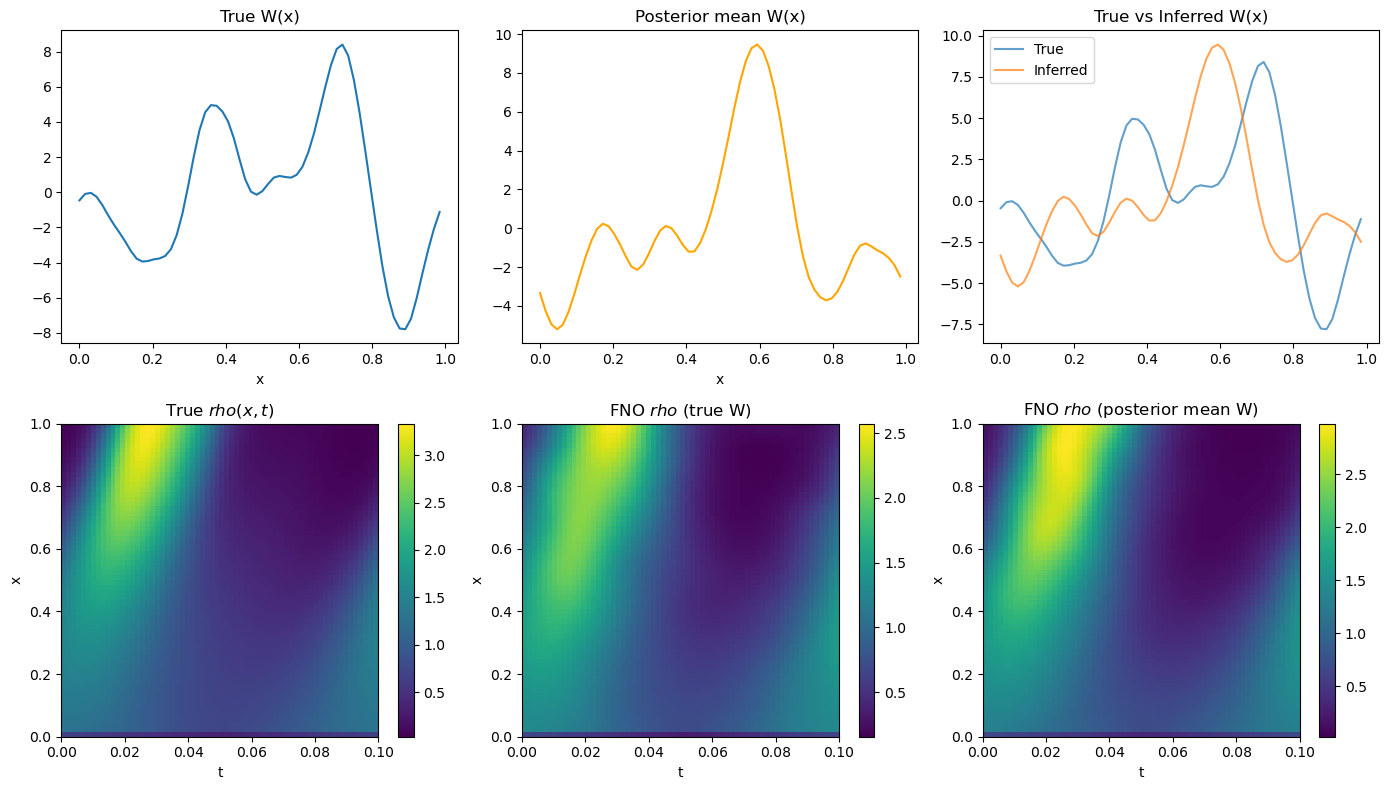

In [60]:
# Posterior mean of W
burnin = MCMC_n_iterations // 2
W_posterior_mean = np.mean(theta_evolution[burnin:], axis=0)  # shape (N,)

x_plot = np.linspace(0, 1, data_train_resolution, endpoint=False)

# Posterior mean prediction
W_mean_tensor = build_fno_input(W_posterior_mean, data_train_resolution)
with torch.no_grad():
    rho_predicted = model(W_mean_tensor).cpu().numpy()[0, 0]
rho_predicted = rho_predicted * rho_std + rho_mean  # unnormalise

# True W prediction
W_true_tensor = build_fno_input(W_obs_np, data_train_resolution)
with torch.no_grad():
    rho_fno_true = model(W_true_tensor).cpu().numpy()[0, 0]
rho_fno_true = rho_fno_true * rho_std + rho_mean  # unnormalise
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Row 1: interaction potentials
axes[0, 0].plot(x_plot, W_obs_np, label="True W")
axes[0, 0].set_title("True W(x)")
axes[0, 0].set_xlabel("x")

axes[0, 1].plot(x_plot, W_posterior_mean, label="Posterior mean", color="orange")
axes[0, 1].set_title("Posterior mean W(x)")
axes[0, 1].set_xlabel("x")

axes[0, 2].plot(x_plot, W_obs_np, label="True", alpha=0.7)
axes[0, 2].plot(x_plot, W_posterior_mean, label="Inferred", alpha=0.7)
axes[0, 2].legend()
axes[0, 2].set_title("True vs Inferred W(x)")

# Row 2: rho(x,t) spacetime fields
extent = [0, 0.1, 0, 1]  # [t_min, t_max, x_min, x_max]
im0 = axes[1, 0].imshow(rho_obs_np, aspect="auto", origin="lower", extent=extent)
axes[1, 0].set_title(r"True $rho(x,t)$")
axes[1, 0].set_xlabel("t"); axes[1, 0].set_ylabel("x")
plt.colorbar(im0, ax=axes[1, 0])

im1 = axes[1, 1].imshow(rho_fno_true, aspect="auto", origin="lower", extent=extent)
axes[1, 1].set_title(r"FNO $rho$ (true W)")
axes[1, 1].set_xlabel("t"); axes[1, 1].set_ylabel("x")
plt.colorbar(im1, ax=axes[1, 1])

im2 = axes[1, 2].imshow(rho_predicted, aspect="auto", origin="lower", extent=extent)
axes[1, 2].set_title(r"FNO $rho$ (posterior mean W)")
axes[1, 2].set_xlabel("t"); axes[1, 2].set_ylabel("x")
plt.colorbar(im2, ax=axes[1, 2])

plt.tight_layout()
plt.show()

In [61]:
# Quantitative errors
rho_obs_tensor = torch.tensor(rho_obs_np[np.newaxis, np.newaxis], dtype=torch.float32)
rho_pred_tensor = torch.tensor(rho_predicted[np.newaxis, np.newaxis], dtype=torch.float32)
rho_fno_tensor  = torch.tensor(rho_fno_true[np.newaxis, np.newaxis], dtype=torch.float32)

print("--- FNO under true W (best possible) ---")
print(f"H1: {h1loss(rho_fno_tensor, rho_obs_tensor).item():.4f}")
print(f"L2: {l2loss(rho_fno_tensor, rho_obs_tensor).item():.4f}")

print("--- FNO under posterior mean W ---")
print(f"H1: {h1loss(rho_pred_tensor, rho_obs_tensor).item():.4f}")
print(f"L2: {l2loss(rho_pred_tensor, rho_obs_tensor).item():.4f}")


--- FNO under true W (best possible) ---
H1: 0.3832
L2: 0.1934
--- FNO under posterior mean W ---
H1: 0.1823
L2: 0.0865


In [62]:
# NLL under true W vs posterior mean W
ll_true = log_likelihood(W_obs_np, rho_obs_np, model, sigma=sigma)
print(f"NLL with true W:           {-ll_true:.4f}")
print(f"NLL with posterior mean W: {-ll_current:.4f}")


NLL with true W:           215.2884
NLL with posterior mean W: 42.0473


L2 error on W: 4.8858


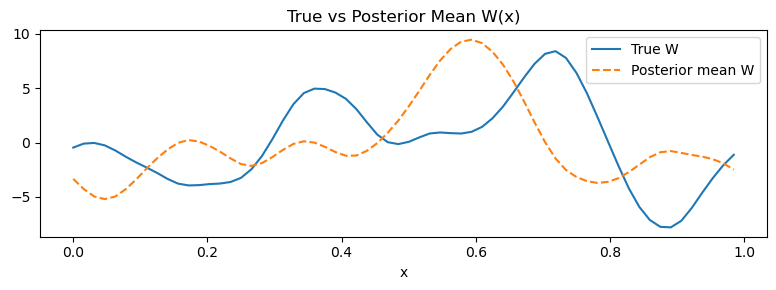

In [63]:
# L2 error on W itself
W_err = np.mean((W_posterior_mean - W_obs_np)**2)**0.5
print(f"L2 error on W: {W_err:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(x_plot, W_obs_np, label="True W")
plt.plot(x_plot, W_posterior_mean, label="Posterior mean W", linestyle="--")
plt.legend()
plt.title("True vs Posterior Mean W(x)")
plt.xlabel("x")
plt.tight_layout()
plt.show()


In [64]:
# Estimate a reasonable sigma from FNO error on true W
with torch.no_grad():
    rho_pred_true = model(build_fno_input(W_obs_np, data_train_resolution))
    rho_pred_true_np = rho_pred_true.cpu().numpy()[0, 0] * rho_std + rho_mean
    residuals = rho_obs_np - rho_pred_true_np
    print(f"Suggested sigma: {residuals.std():.4f}")


Suggested sigma: 0.2388


Text(0.5, 1.0, 'Mean absolute change per step')

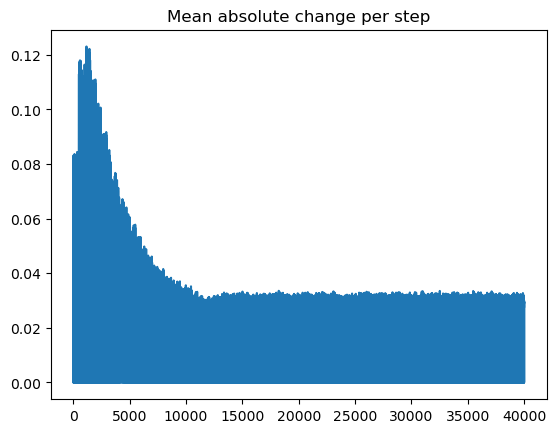

In [65]:
# Plot how much the chain moves each step
diffs = [np.mean(np.abs(theta_evolution[i] - theta_evolution[i-1])) 
         for i in range(1, len(theta_evolution))]
plt.plot(diffs)
plt.title("Mean absolute change per step")

In [66]:
print(f"sigma = {sigma:.4f}")
print(f"rho range: [{rho_obs_np.min():.4f}, {rho_obs_np.max():.4f}]")

sigma = 0.7374
rho range: [0.0283, 3.3343]


In [67]:
# How different are two random W's rho outputs?
W1 = sample_W_prior(N=data_train_resolution)
W2 = sample_W_prior(N=data_train_resolution)
with torch.no_grad():
    r1 = model(build_fno_input(W1, data_train_resolution)).cpu().numpy()[0,0]
    r2 = model(build_fno_input(W2, data_train_resolution)).cpu().numpy()[0,0]
print(f"Mean |rho1 - rho2|: {np.mean(np.abs(r1 - r2)):.4f}")
print(f"Mean |rho_true - rho1|: {np.mean(np.abs(rho_obs_np - r1)):.4f}")

Mean |rho1 - rho2|: 0.7442
Mean |rho_true - rho1|: 0.9929


In [68]:
# Test what sigma_W you need
for sigma_W in [0.1, 0.5, 1.0, 2.0, 5.0]:
    W1 = sample_negative_laplacian(sigma=sigma_W, tau=3, alpha=4, N=data_train_resolution)
    W2 = sample_negative_laplacian(sigma=sigma_W, tau=3, alpha=4, N=data_train_resolution)
    with torch.no_grad():
        r1 = model(build_fno_input(W1, data_train_resolution)).cpu().numpy()[0,0]
        r2 = model(build_fno_input(W2, data_train_resolution)).cpu().numpy()[0,0]
    print(f"sigma_W={sigma_W:.1f} | |rho1-rho2|={np.mean(np.abs(r1-r2)):.4f}")

sigma_W=0.1 | |rho1-rho2|=0.0052
sigma_W=0.5 | |rho1-rho2|=0.0152
sigma_W=1.0 | |rho1-rho2|=0.0429
sigma_W=2.0 | |rho1-rho2|=0.0920
sigma_W=5.0 | |rho1-rho2|=0.0028
